### **Введение**

Рак остается одной из основных причин смертности во всем мире. Одной из ключевых проблем в современной онкологии является индивидуальная вариабельность реакции пациентов на противораковую терапию. Лечение, эффективное для одного пациента, может оказаться совершенно бесполезным для другого, что приводит к потере драгоценного времени и подверганию пациента ненужным побочным эффектам.

В эпоху персонализированной медицины машинное обучение открывает новые возможности для прогнозирования эффективности лечения. Анализ геномных и молекулярных данных позволяет выявить биомаркеры, ассоциированные с чувствительностью или резистентностью к конкретным лекарственным препаратам.

Данная работа посвящена решению задачи предсказания чувствительности раковых клеточных линий к лекарствам на основе их молекулярных профилей. В качестве набора данных используется **Drug Sensitivity in Cancer (GDSC)**, который содержит информацию о метаболических, генетических признаках и результатах скрининга тысяч клеточных линий в ответ на различные противораковые соединения.

Цель работы — построить и оценить модель машинного обучения, которая по генетическим и молекулярным характеристикам сможет предсказать **IC50** — концентрацию препарата, необходимую для подавления роста клеток на 50%, что является стандартной мерой эффективности лекарства.

Основные этапы работы включают:
1.  **Предобработку и анализ данных.**
2.  **Отбор наиболее информативных признаков** для повышения эффективности и интерпретируемости модели.
3.  **Обучение и тестирование моделей** как регрессии (для точного предсказания значения IC50), так и классификации (для категоризации клеток на "чувствительные" и "резистентные").
4.  **Сравнительный анализ** результатов и выбор наилучшей модели.

Успешное решение этой задачи является важным шагом на пути к разработке алгоритмов, способных помочь врачам в выборе оптимальной схемы лечения для каждого конкретного пациента.

### **Обработка данных: устранение пропусков, масштабирование признаков.**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

/home/alekseevnikolay/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
gdsc_dataset = pd.read_csv('data/GDSC_DATASET.csv')
compounds_annotation = pd.read_csv('data/Compounds-annotation.csv')
gdsc2_dataset = pd.read_csv('data/GDSC2-dataset.csv')
cell_lines_details = pd.read_excel('data/Cell_Lines_Details.xlsx')

/home/alekseevnikolay/.local/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
display(gdsc_dataset.head())
display(compounds_annotation.head())
display(gdsc2_dataset.head())
display(cell_lines_details.head())

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


,DRUG_ID,SCREENING_SITE,DRUG_NAME,SYNONYMS,TARGET,TARGET_PATHWAY
0,1,MGH,Erlotinib,"Tarceva, RG-1415, CP-358774, OSI-774, Ro-50823...",EGFR,EGFR signaling
1,3,MGH,Rapamycin,"AY-22989, Sirolimus, WY-090217, Torisel, Rapamune",MTORC1,PI3K/MTOR signaling
2,5,MGH,Sunitinib,"Sutent, Sunitinib Malate, SU-11248","PDGFR, KIT, VEGFR, FLT3, RET, CSF1R",RTK signaling
3,6,MGH,PHA-665752,"PHA665752, PHA 665752",MET,RTK signaling
4,9,MGH,MG-132,"LLL cpd, MG 132, MG132","Proteasome, CAPN1",Protein stability and degradation


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


,Sample Name,COSMIC identifier,Whole Exome Sequencing (WES),Copy Number Alterations (CNA),Gene Expression,Methylation,Drug\nResponse,GDSC\nTissue descriptor 1,GDSC\nTissue\ndescriptor 2,Cancer Type\n(matching TCGA label),Microsatellite \ninstability Status (MSI),Screen Medium,Growth Properties
0,A253,906794.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,NaN,MSS/MSI-L,D/F12,Adherent
1,BB30-HNC,753531.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
2,BB49-HNC,753532.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
3,BHY,753535.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent
4,BICR10,1290724.0,Y,Y,Y,Y,Y,aero_dig_tract,head and neck,HNSC,MSS/MSI-L,D/F12,Adherent


In [4]:
display(gdsc_dataset.describe())
display(compounds_annotation.describe())
display(gdsc2_dataset.describe())
display(cell_lines_details.describe())

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE
count,2.420350e+05,242035.000000,242035.000000,242035.000000,242035.000000
mean,9.921071e+05,1594.044886,2.817111,0.882593,0.000006
std,2.209814e+05,398.739728,2.762191,0.146998,0.999390
min,6.836670e+05,1003.000000,-8.747724,0.006282,-8.254501
25%,9.068050e+05,1149.000000,1.508054,0.849452,-0.656842
50%,9.097200e+05,1631.000000,3.236744,0.944197,0.010585
75%,1.240144e+06,1912.000000,4.700111,0.974934,0.656036
max,1.789883e+06,2499.000000,13.820189,0.998904,7.978776


,DRUG_ID
count,621.000000
mean,1075.953301
std,686.876976
min,1.000000
25%,305.000000
50%,1168.000000
75%,1629.000000
max,2499.000000


,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,DRUG_ID,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
count,242036.0,2.420360e+05,2.420360e+05,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,242036.000000,2.420360e+05
mean,343.0,1.606806e+07,9.921059e+05,1594.042444,1042.966604,0.023143,23.462279,2.817079,0.882592,0.082779,7.312962e-10
std,0.0,7.028749e+04,2.209819e+05,398.740714,16.911327,0.158738,158.622810,2.762229,0.146998,0.042695,9.993925e-01
min,343.0,1.594631e+07,6.836670e+05,1003.000000,1001.000000,0.000010,0.010000,-8.747724,0.006282,0.003274,-8.254501e+00
25%,343.0,1.600719e+07,9.068050e+05,1149.000000,1043.000000,0.003002,3.000000,1.508018,0.849449,0.051107,-6.568485e-01
50%,343.0,1.606807e+07,9.097200e+05,1631.000000,1046.000000,0.010005,10.000000,3.236731,0.944196,0.076083,1.058000e-02
75%,343.0,1.612893e+07,1.240144e+06,1912.000000,1046.000000,0.010005,10.000000,4.700110,0.974934,0.106105,6.560362e-01
max,343.0,1.618978e+07,1.789883e+06,2499.000000,1101.000000,2.001054,2000.000000,13.820189,0.998904,0.299984,7.978776e+00


,COSMIC identifier
count,1.001000e+03
mean,9.949581e+05
std,2.241654e+05
min,6.836650e+05
25%,9.068120e+05
50%,9.097270e+05
75%,1.240154e+06
max,1.789883e+06


In [5]:
# Check for missing values
print(gdsc_dataset.isnull().sum())
print(compounds_annotation.isnull().sum())
print(gdsc2_dataset.isnull().sum())
print(cell_lines_details.isnull().sum())

COSMIC_ID                                      0
CELL_LINE_NAME                                 0
TCGA_DESC                                   1067
DRUG_ID                                        0
DRUG_NAME                                      0
LN_IC50                                        0
AUC                                            0
Z_SCORE                                        0
GDSC Tissue descriptor 1                    9366
GDSC Tissue descriptor 2                    9366
Cancer Type (matching TCGA label)          51446
Microsatellite instability Status (MSI)    12353
Screen Medium                               9366
Growth Properties                           9366
CNA                                         9366
Gene Expression                             9366
Methylation                                 9366
TARGET                                     27155
TARGET_PATHWAY                                 0
dtype: int64
DRUG_ID             0
SCREENING_SITE      0
DRUG_NAME   

In [4]:
gdsc_dataset = gdsc_dataset.dropna()
compounds_annotation = compounds_annotation.dropna()
gdsc2_dataset = gdsc2_dataset.dropna()
cell_lines_details = cell_lines_details.dropna()

=== Масштабирование LN_IC50 ===
GDSC1 - LN_IC50 до масштабирования:
min: -8.64, max: 13.82, mean: 2.84
GDSC1 - LN_IC50 после масштабирования:
min: -4.06, max: 3.89, mean: -0.00

GDSC2 - LN_IC50 до масштабирования:
min: -8.75, max: 13.82, mean: 2.78
GDSC2 - LN_IC50 после масштабирования:
min: -4.07, max: 3.89, mean: -0.00


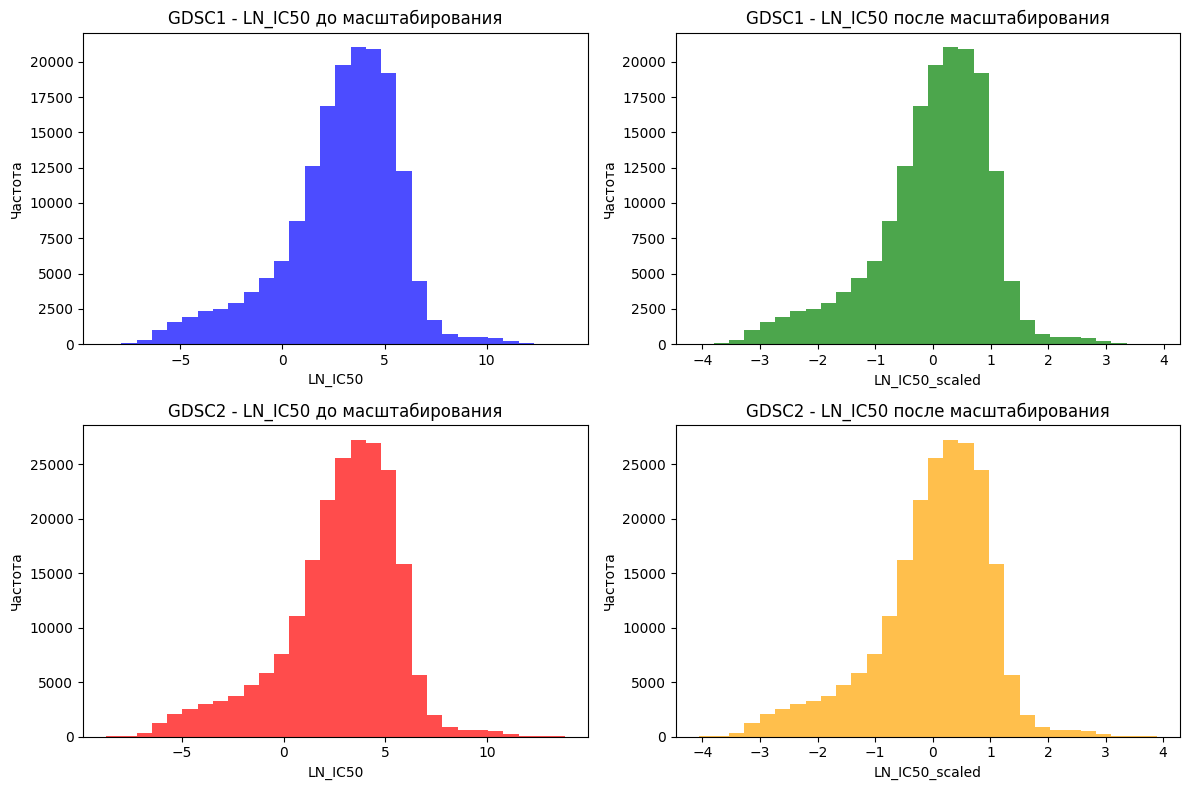


=== Результаты масштабирования ===
GDSC1: создан столбец 'LN_IC50_scaled'
GDSC2: создан столбец 'LN_IC50_scaled'

GDSC1 первые 3 строки с масштабированными значениями:
    LN_IC50  LN_IC50_scaled
0 -1.463887       -1.523914
5 -1.235034       -1.442914
7 -2.963191       -2.054572


In [5]:
# Масштабируем только LN_IC50 в обеих таблицах
scaler = StandardScaler()

# Проверим наличие LN_IC50 в таблицах и масштабируем
print("=== Масштабирование LN_IC50 ===")

# Для gdsc_dataset
if 'LN_IC50' in gdsc_dataset.columns:
    print(f"GDSC1 - LN_IC50 до масштабирования:")
    print(f"min: {gdsc_dataset['LN_IC50'].min():.2f}, max: {gdsc_dataset['LN_IC50'].max():.2f}, mean: {gdsc_dataset['LN_IC50'].mean():.2f}")
    
    # Масштабируем LN_IC50
    gdsc_dataset['LN_IC50_scaled'] = scaler.fit_transform(gdsc_dataset[['LN_IC50']])
    
    print(f"GDSC1 - LN_IC50 после масштабирования:")
    print(f"min: {gdsc_dataset['LN_IC50_scaled'].min():.2f}, max: {gdsc_dataset['LN_IC50_scaled'].max():.2f}, mean: {gdsc_dataset['LN_IC50_scaled'].mean():.2f}")
else:
    print("LN_IC50 не найден в gdsc_dataset")

# Для gdsc2_dataset
if 'LN_IC50' in gdsc2_dataset.columns:
    print(f"\nGDSC2 - LN_IC50 до масштабирования:")
    print(f"min: {gdsc2_dataset['LN_IC50'].min():.2f}, max: {gdsc2_dataset['LN_IC50'].max():.2f}, mean: {gdsc2_dataset['LN_IC50'].mean():.2f}")
    
    # Масштабируем LN_IC50
    gdsc2_dataset['LN_IC50_scaled'] = scaler.fit_transform(gdsc2_dataset[['LN_IC50']])
    
    print(f"GDSC2 - LN_IC50 после масштабирования:")
    print(f"min: {gdsc2_dataset['LN_IC50_scaled'].min():.2f}, max: {gdsc2_dataset['LN_IC50_scaled'].max():.2f}, mean: {gdsc2_dataset['LN_IC50_scaled'].mean():.2f}")
else:
    print("LN_IC50 не найден в gdsc2_dataset")

# Визуализируем распределение до и после масштабирования
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

if 'LN_IC50' in gdsc_dataset.columns:
    # GDSC1 до масштабирования
    axes[0, 0].hist(gdsc_dataset['LN_IC50'], bins=30, alpha=0.7, color='blue')
    axes[0, 0].set_title('GDSC1 - LN_IC50 до масштабирования')
    axes[0, 0].set_xlabel('LN_IC50')
    axes[0, 0].set_ylabel('Частота')
    
    # GDSC1 после масштабирования
    axes[0, 1].hist(gdsc_dataset['LN_IC50_scaled'], bins=30, alpha=0.7, color='green')
    axes[0, 1].set_title('GDSC1 - LN_IC50 после масштабирования')
    axes[0, 1].set_xlabel('LN_IC50_scaled')
    axes[0, 1].set_ylabel('Частота')

if 'LN_IC50' in gdsc2_dataset.columns:
    # GDSC2 до масштабирования
    axes[1, 0].hist(gdsc2_dataset['LN_IC50'], bins=30, alpha=0.7, color='red')
    axes[1, 0].set_title('GDSC2 - LN_IC50 до масштабирования')
    axes[1, 0].set_xlabel('LN_IC50')
    axes[1, 0].set_ylabel('Частота')
    
    # GDSC2 после масштабирования
    axes[1, 1].hist(gdsc2_dataset['LN_IC50_scaled'], bins=30, alpha=0.7, color='orange')
    axes[1, 1].set_title('GDSC2 - LN_IC50 после масштабирования')
    axes[1, 1].set_xlabel('LN_IC50_scaled')
    axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("\n=== Результаты масштабирования ===")
if 'LN_IC50_scaled' in gdsc_dataset.columns:
    print(f"GDSC1: создан столбец 'LN_IC50_scaled'")
if 'LN_IC50_scaled' in gdsc2_dataset.columns:
    print(f"GDSC2: создан столбец 'LN_IC50_scaled'")

# Покажем первые несколько строк с масштабированными значениями
if 'LN_IC50_scaled' in gdsc_dataset.columns:
    print("\nGDSC1 первые 3 строки с масштабированными значениями:")
    print(gdsc_dataset[['LN_IC50', 'LN_IC50_scaled']].head(3))

In [6]:
display(gdsc_dataset.describe())
display(gdsc2_dataset.describe())

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE,LN_IC50_scaled
count,1.666440e+05,166644.000000,166644.000000,166644.000000,166644.000000,1.666440e+05
mean,9.863868e+05,1556.705228,2.841726,0.880922,0.042397,-1.910199e-16
std,2.244093e+05,405.862644,2.825374,0.147861,1.000177,1.000003e+00
min,6.836670e+05,1003.000000,-8.642551,0.006282,-6.909716,-4.064705e+00
25%,9.059780e+05,1086.000000,1.505524,0.847475,-0.613185,-4.729310e-01
50%,9.092630e+05,1613.000000,3.292250,0.942172,0.052380,1.594566e-01
75%,1.240145e+06,1910.000000,4.777961,0.974163,0.690165,6.853044e-01
max,1.674021e+06,2499.000000,13.820189,0.998904,7.978776,3.885679e+00


,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,DRUG_ID,COMPANY_ID,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE,LN_IC50_scaled
count,213825.0,2.138250e+05,2.138250e+05,213825.000000,213825.000000,213825.000000,213825.000000,213825.000000,213825.000000,213825.000000,213825.000000,2.138250e+05
mean,343.0,1.606822e+07,9.920486e+05,1556.723073,1043.251687,0.025027,25.389320,2.782278,0.878898,0.083412,0.000158,-1.190967e-16
std,0.0,7.030813e+04,2.207273e+05,405.615983,16.930245,0.168639,168.512265,2.834689,0.150944,0.043130,0.999314,1.000002e+00
min,343.0,1.594631e+07,6.836670e+05,1003.000000,1001.000000,0.000010,0.010000,-8.747724,0.006282,0.003274,-8.254501,-4.067475e+00
25%,343.0,1.600725e+07,9.068050e+05,1086.000000,1046.000000,0.003002,5.000000,1.451398,0.844762,0.051515,-0.655009,-4.694986e-01
50%,343.0,1.606858e+07,9.097220e+05,1613.000000,1046.000000,0.010005,10.000000,3.237726,0.941706,0.076622,0.010700,1.606700e-01
75%,343.0,1.612908e+07,1.240144e+06,1910.000000,1046.000000,0.010005,10.000000,4.720382,0.974348,0.106980,0.654810,6.837112e-01
max,343.0,1.618978e+07,1.789883e+06,2499.000000,1101.000000,2.001054,2000.000000,13.820189,0.998904,0.299984,7.978776,3.893879e+00


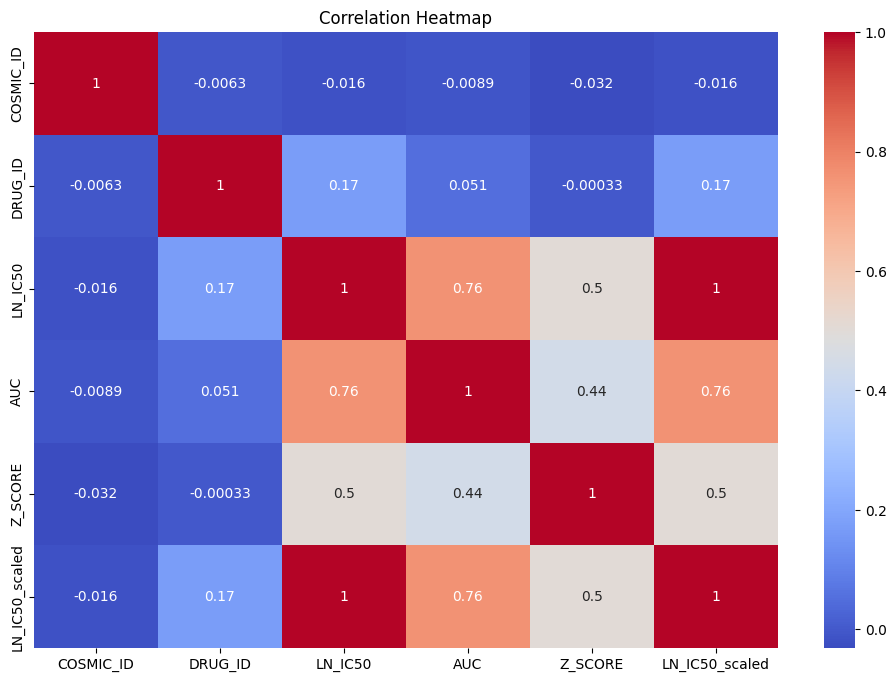

In [7]:
# Select only numeric columns for correlation analysis
numeric_df = gdsc_dataset.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [8]:
# Merge GDSC2 dataset with Cell Lines Details on COSMIC_ID
merged_df = pd.merge(gdsc2_dataset, cell_lines_details, left_on='COSMIC_ID', right_on='COSMIC identifier', how='left')

# Merge the resulting dataframe with Compounds Annotation on DRUG_ID
final_df = pd.merge(merged_df, compounds_annotation, on='DRUG_ID', how='left')
final_df.head()

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME_x,PUTATIVE_TARGET,...,GDSC\nTissue\ndescriptor 2,Cancer Type\n(matching TCGA label),Microsatellite \ninstability Status (MSI),Screen Medium,Growth Properties,SCREENING_SITE,DRUG_NAME_y,SYNONYMS,TARGET,TARGET_PATHWAY
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,...,medulloblastoma,MB,MSS/MSI-L,R,Adherent,SANGER,Camptothecin,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,...,NaN,NaN,NaN,NaN,NaN,SANGER,Camptothecin,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,...,NaN,NaN,NaN,NaN,NaN,SANGER,Camptothecin,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,...,NaN,NaN,NaN,NaN,NaN,SANGER,Camptothecin,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,...,NaN,NaN,NaN,NaN,NaN,SANGER,Camptothecin,"Camptothecine, (+)-Camptothecin",TOP1,DNA replication


### **Выделение признаков: корреляционный анализ, отбор значимых переменных.**

In [9]:
# Выделим числовые признаки для корреляционного анализа
numeric_final = final_df.select_dtypes(include=[np.number])
print(f"Числовых признаков: {numeric_final.shape[1]}")
print(f"Строк с числовыми данными: {numeric_final.shape[0]}")

# Проверим целевую переменную
target_column = 'LN_IC50_scaled' if 'LN_IC50_scaled' in final_df.columns else 'LN_IC50'
print(f"Целевая переменная: {target_column}")

Числовых признаков: 13
Строк с числовыми данными: 213825
Целевая переменная: LN_IC50_scaled


=== КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
Наиболее позитивно коррелирующие признаки с LN_IC50_scaled:
LN_IC50              1.000000
LN_IC50_scaled       1.000000
AUC                  0.764093
Z_SCORE              0.500249
MAX_CONC             0.258722
MIN_CONC             0.258117
DRUG_ID              0.173836
COMPANY_ID           0.131732
COSMIC identifier   -0.011039
COSMIC_ID           -0.011923
Name: LN_IC50_scaled, dtype: float64

Наиболее негативно коррелирующие признаки с LN_IC50_scaled:
Z_SCORE              0.500249
MAX_CONC             0.258722
MIN_CONC             0.258117
DRUG_ID              0.173836
COMPANY_ID           0.131732
COSMIC identifier   -0.011039
COSMIC_ID           -0.011923
NLME_CURVE_ID       -0.015070
RMSE                -0.432145
NLME_RESULT_ID            NaN
Name: LN_IC50_scaled, dtype: float64


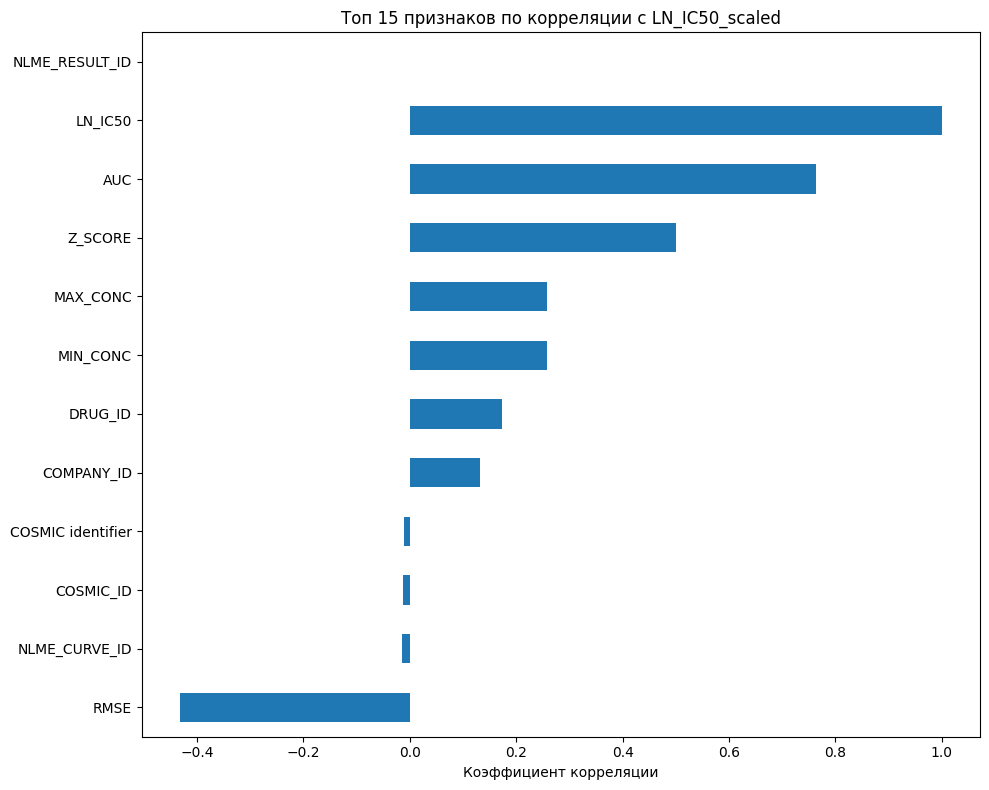

In [10]:
if target_column in numeric_final.columns:
    correlations = numeric_final.corr()[target_column].sort_values(ascending=False)
    
    print("=== КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")
    print(f"Наиболее позитивно коррелирующие признаки с {target_column}:")
    print(correlations.head(10))
    
    print(f"\nНаиболее негативно коррелирующие признаки с {target_column}:")
    print(correlations.tail(10))
    
    # Визуализация топ коррелирующих признаков
    top_corr = correlations.drop(target_column).head(15)
    
    plt.figure(figsize=(10, 8))
    top_corr.sort_values().plot(kind='barh')
    plt.title(f'Топ 15 признаков по корреляции с {target_column}')
    plt.xlabel('Коэффициент корреляции')
    plt.tight_layout()
    plt.show()

In [11]:
# Установим порог корреляции для отбора признаков
correlation_threshold = 0.1

significant_features = correlations[
    (abs(correlations) > correlation_threshold) & 
    (correlations.index != target_column) & (correlations.index != "LN_IC50")
]

print(f"=== ОТБОР ПРИЗНАКОВ ПО ПОРОГУ КОРРЕЛЯЦИИ {correlation_threshold} ===")
print(f"Отобрано признаков: {len(significant_features)}")
print("Значимые признаки:")

for feature, corr in significant_features.items():
    print(f"{feature}: {corr:.3f}")

=== ОТБОР ПРИЗНАКОВ ПО ПОРОГУ КОРРЕЛЯЦИИ 0.1 ===
Отобрано признаков: 7
Значимые признаки:
AUC: 0.764
Z_SCORE: 0.500
MAX_CONC: 0.259
MIN_CONC: 0.258
DRUG_ID: 0.174
COMPANY_ID: 0.132
RMSE: -0.432


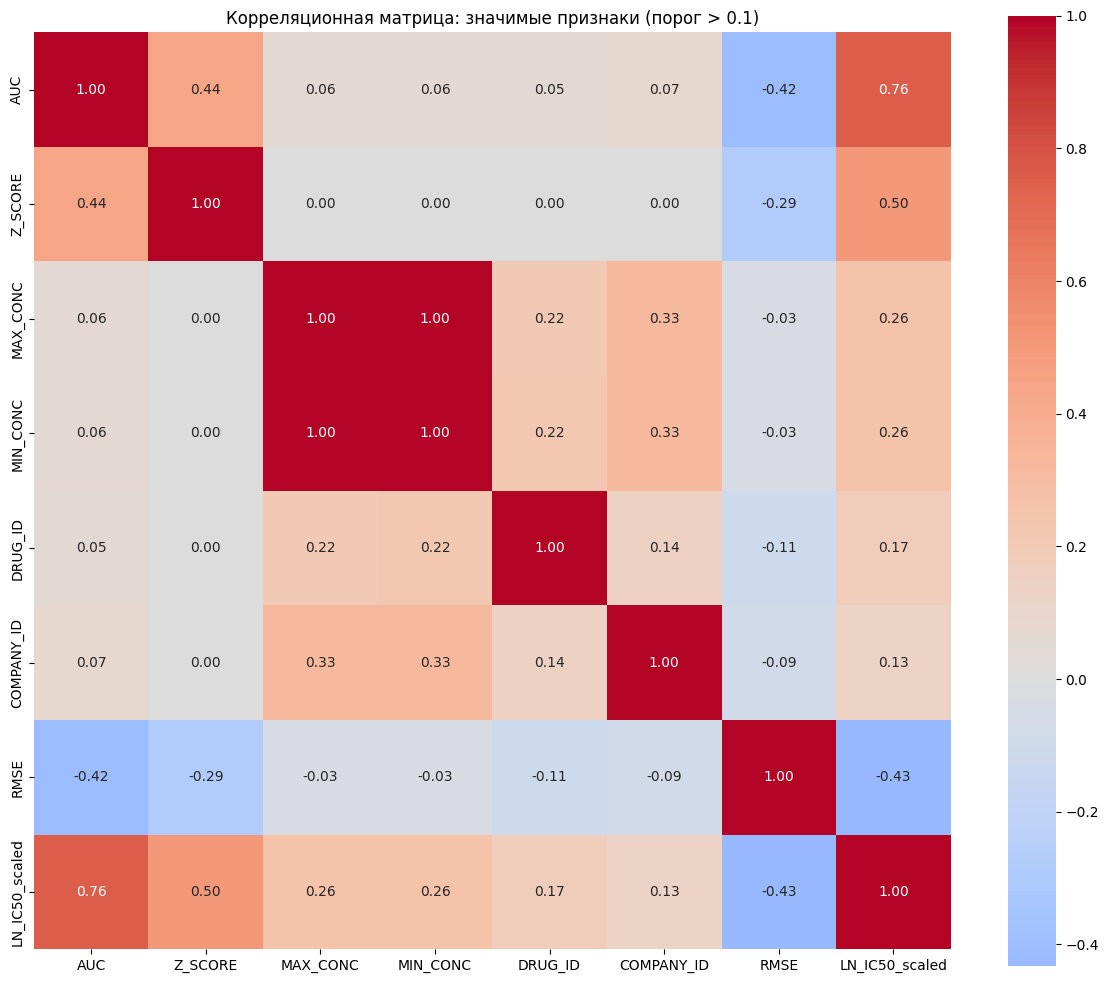

In [12]:
# ВИЗУАЛИЗАЦИЯ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ

# Создаем матрицу только для значимых признаков + целевая переменная
final_features = list(significant_features.index)
selected_features = list(significant_features.index) + [target_column]
selected_corr_matrix = numeric_final[selected_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(selected_corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True)
plt.title(f'Корреляционная матрица: значимые признаки (порог > {correlation_threshold})')
plt.tight_layout()
plt.show()

In [13]:
# СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ОТБОРА ПРИЗНАКОВ

print("=== ИТОГИ ОТБОРА ПРИЗНАКОВ ===")
print(f"Целевая переменная: {target_column}")
print(f"Отобрано признаков: {len(final_features)}")
print(f"Список признаков для моделирования:")
for i, feature in enumerate(final_features, 1):
    print(f"{i}. {feature}")

# Создаем финальный датасет для моделирования
X_final = numeric_final[final_features]
y_final = final_df[target_column]

print(f"\nФинальная размерность для моделирования:")
print(f"X: {X_final.shape}")
print(f"y: {y_final.shape}")

# Удаляем строки с пропусками в финальном наборе
final_indices = X_final.dropna().index.intersection(y_final.dropna().index)
X_final_clean = X_final.loc[final_indices]
y_final_clean = y_final.loc[final_indices]

print(f"\nПосле удаления пропусков:")
print(f"X: {X_final_clean.shape}")
print(f"y: {y_final_clean.shape}")

=== ИТОГИ ОТБОРА ПРИЗНАКОВ ===
Целевая переменная: LN_IC50_scaled
Отобрано признаков: 7
Список признаков для моделирования:
1. AUC
2. Z_SCORE
3. MAX_CONC
4. MIN_CONC
5. DRUG_ID
6. COMPANY_ID
7. RMSE

Финальная размерность для моделирования:
X: (213825, 7)
y: (213825,)

После удаления пропусков:
X: (213825, 7)
y: (213825,)


### **Выбор модели: регрессия, случайный лес, градиентный бустинг, нейросети.**

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [15]:
# ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ

print("=== ПОДГОТОВКА ДАННЫХ ===")
print(f"Размерность X: {X_final_clean.shape}")
print(f"Размерность y: {y_final_clean.shape}")

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_final_clean, y_final_clean, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

=== ПОДГОТОВКА ДАННЫХ ===
Размерность X: (213825, 7)
Размерность y: (213825,)
Обучающая выборка: (171060, 7)
Тестовая выборка: (42765, 7)


In [16]:
# БАЗОВЫЕ МОДЕЛИ РЕГРЕССИИ

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

In [17]:
# ФУНКЦИЯ ДЛЯ ОЦЕНКИ МОДЕЛЕЙ

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Оценка производительности модели"""
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'Train R2': r2_score(y_train, y_pred_train),
        'Test R2': r2_score(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test)
    }
    
    return metrics, y_pred_test

In [18]:
# СРАВНЕНИЕ МОДЕЛЕЙ

results = {}
predictions = {}

print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print("Обучаю модели...")

for name, model in models.items():
    print(f"Обучение: {name}")
    metrics, y_pred = evaluate_model(model, X_train, X_test, y_train, y_test)
    results[name] = metrics
    predictions[name] = y_pred

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
Обучаю модели...
Обучение: Linear Regression
Обучение: Ridge Regression
Обучение: Lasso Regression
Обучение: Random Forest
Обучение: Gradient Boosting
Обучение: Neural Network


In [19]:
# ТАБЛИЦА РЕЗУЛЬТАТОВ

results_df = pd.DataFrame(results).T
print("=== РЕЗУЛЬТАТЫ МОДЕЛЕЙ ===")
print(results_df.round(4))

# Сортируем по Test R2 (основная метрика)
results_sorted = results_df.sort_values('Test R2', ascending=False)
print("\n=== РЕЙТИНГ МОДЕЛЕЙ (по Test R2) ===")
print(results_sorted[['Test R2', 'Test RMSE', 'Test MAE']].round(4))

=== РЕЗУЛЬТАТЫ МОДЕЛЕЙ ===
                   Train R2  Test R2  Train RMSE  Test RMSE  Train MAE  \
Linear Regression    0.6810   0.6904      0.5645     0.5576     0.3862   
Ridge Regression     0.6807   0.6901      0.5647     0.5578     0.3856   
Lasso Regression     0.3227   0.3252      0.8225     0.8232     0.6169   
Random Forest        0.9987   0.9904      0.0367     0.0982     0.0194   
Gradient Boosting    0.9716   0.9714      0.1686     0.1696     0.1273   
Neural Network       0.3600   0.3653      0.7996     0.7984     0.7070   

                   Test MAE  
Linear Regression    0.3844  
Ridge Regression     0.3836  
Lasso Regression     0.6173  
Random Forest        0.0519  
Gradient Boosting    0.1279  
Neural Network       0.7050  

=== РЕЙТИНГ МОДЕЛЕЙ (по Test R2) ===
                   Test R2  Test RMSE  Test MAE
Random Forest       0.9904     0.0982    0.0519
Gradient Boosting   0.9714     0.1696    0.1279
Linear Regression   0.6904     0.5576    0.3844
Ridge Regressi

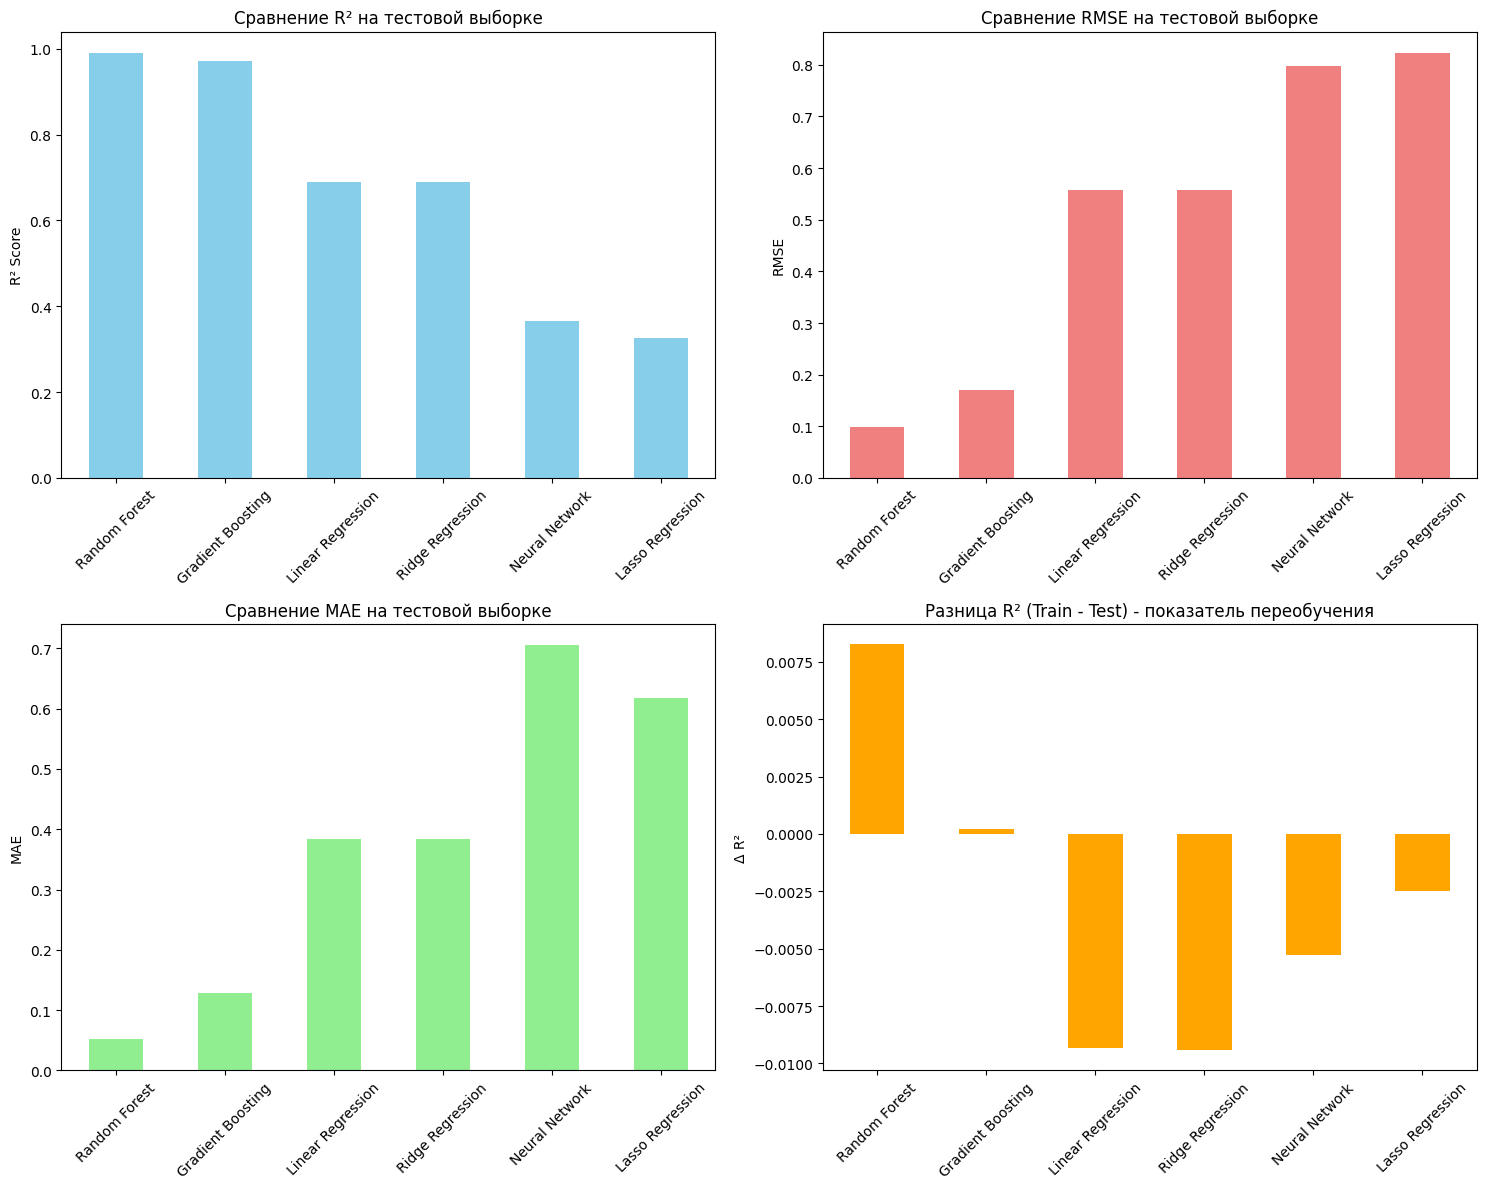

In [20]:
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Сравнение R2
results_sorted['Test R2'].plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Сравнение R² на тестовой выборке')
axes[0,0].set_ylabel('R² Score')
axes[0,0].tick_params(axis='x', rotation=45)

# Сравнение RMSE
results_sorted['Test RMSE'].plot(kind='bar', ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('Сравнение RMSE на тестовой выборке')
axes[0,1].set_ylabel('RMSE')
axes[0,1].tick_params(axis='x', rotation=45)

# Сравнение MAE
results_sorted['Test MAE'].plot(kind='bar', ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Сравнение MAE на тестовой выборке')
axes[1,0].set_ylabel('MAE')
axes[1,0].tick_params(axis='x', rotation=45)

# Разница между Train и Test R2 (переобучение)
(results_sorted['Train R2'] - results_sorted['Test R2']).plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title('Разница R² (Train - Test) - показатель переобучения')
axes[1,1].set_ylabel('Δ R²')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Как итог в качестве основной модели выберем Random Forest, так как именно она имеет лучшие метрики.

### **Кросс-валидация модели Random Forest**

In [21]:
print("=== КОМПЛЕКСНАЯ ОЦЕНКА RANDOM FOREST ===")

# Инициализация модели
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 1. ОБЫЧНОЕ ОБУЧЕНИЕ (train/test split)
print("1. ОБЫЧНОЕ ОБУЧЕНИЕ (train/test split)")
X_train, X_test, y_train, y_test = train_test_split(
    X_final_clean, y_final_clean, test_size=0.2, random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Метрики для обычного обучения
simple_metrics = {
    'R2': r2_score(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'MAE': mean_absolute_error(y_test, y_pred)
}

print(f"Результаты обычного обучения:")
print(f"R²: {simple_metrics['R2']:.4f}")
print(f"RMSE: {simple_metrics['RMSE']:.4f}")
print(f"MAE: {simple_metrics['MAE']:.4f}")

=== КОМПЛЕКСНАЯ ОЦЕНКА RANDOM FOREST ===
1. ОБЫЧНОЕ ОБУЧЕНИЕ (train/test split)
Результаты обычного обучения:
R²: 0.9904
RMSE: 0.0982
MAE: 0.0519


In [ ]:
print("\n2. КРОСС-ВАЛИДАЦИЯ (5-fold)")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Определяем метрики для кросс-валидации
scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

# Выполняем кросс-валидацию
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(rf_model, X_final_clean, y_final_clean, 
                          cv=kf, scoring=scoring, n_jobs=-1, return_train_score=True)

# Обрабатываем результаты кросс-валидации
cv_metrics = {
    'train_r2_mean': cv_results['train_r2'].mean(),
    'train_r2_std': cv_results['train_r2'].std(),
    'test_r2_mean': cv_results['test_r2'].mean(),
    'test_r2_std': cv_results['test_r2'].std(),
    'test_rmse_mean': -cv_results['test_rmse'].mean(),
    'test_rmse_std': cv_results['test_rmse'].std(),
    'test_mae_mean': -cv_results['test_mae'].mean(),
    'test_mae_std': cv_results['test_mae'].std()
}

print("Результаты кросс-валидации:")
print(f"R²: {cv_metrics['test_r2_mean']:.4f} (+/- {cv_metrics['test_r2_std'] * 2:.4f})")
print(f"RMSE: {cv_metrics['test_rmse_mean']:.4f} (+/- {cv_metrics['test_rmse_std'] * 2:.4f})")
print(f"MAE: {cv_metrics['test_mae_mean']:.4f} (+/- {cv_metrics['test_mae_std'] * 2:.4f})")


2. КРОСС-ВАЛИДАЦИЯ (5-fold)


In [24]:
# 1. ВАЖНОСТЬ ПРИЗНАКОВ ОТ RANDOM FOREST
print("=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===")

# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-7 наиболее важных признаков:")
print(feature_importance.head(15).round(4))

=== АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ===
Топ-7 наиболее важных признаков:
      feature  importance
0         AUC      0.6007
2    MAX_CONC      0.2849
1     Z_SCORE      0.0518
3    MIN_CONC      0.0243
4     DRUG_ID      0.0240
5  COMPANY_ID      0.0107
6        RMSE      0.0036


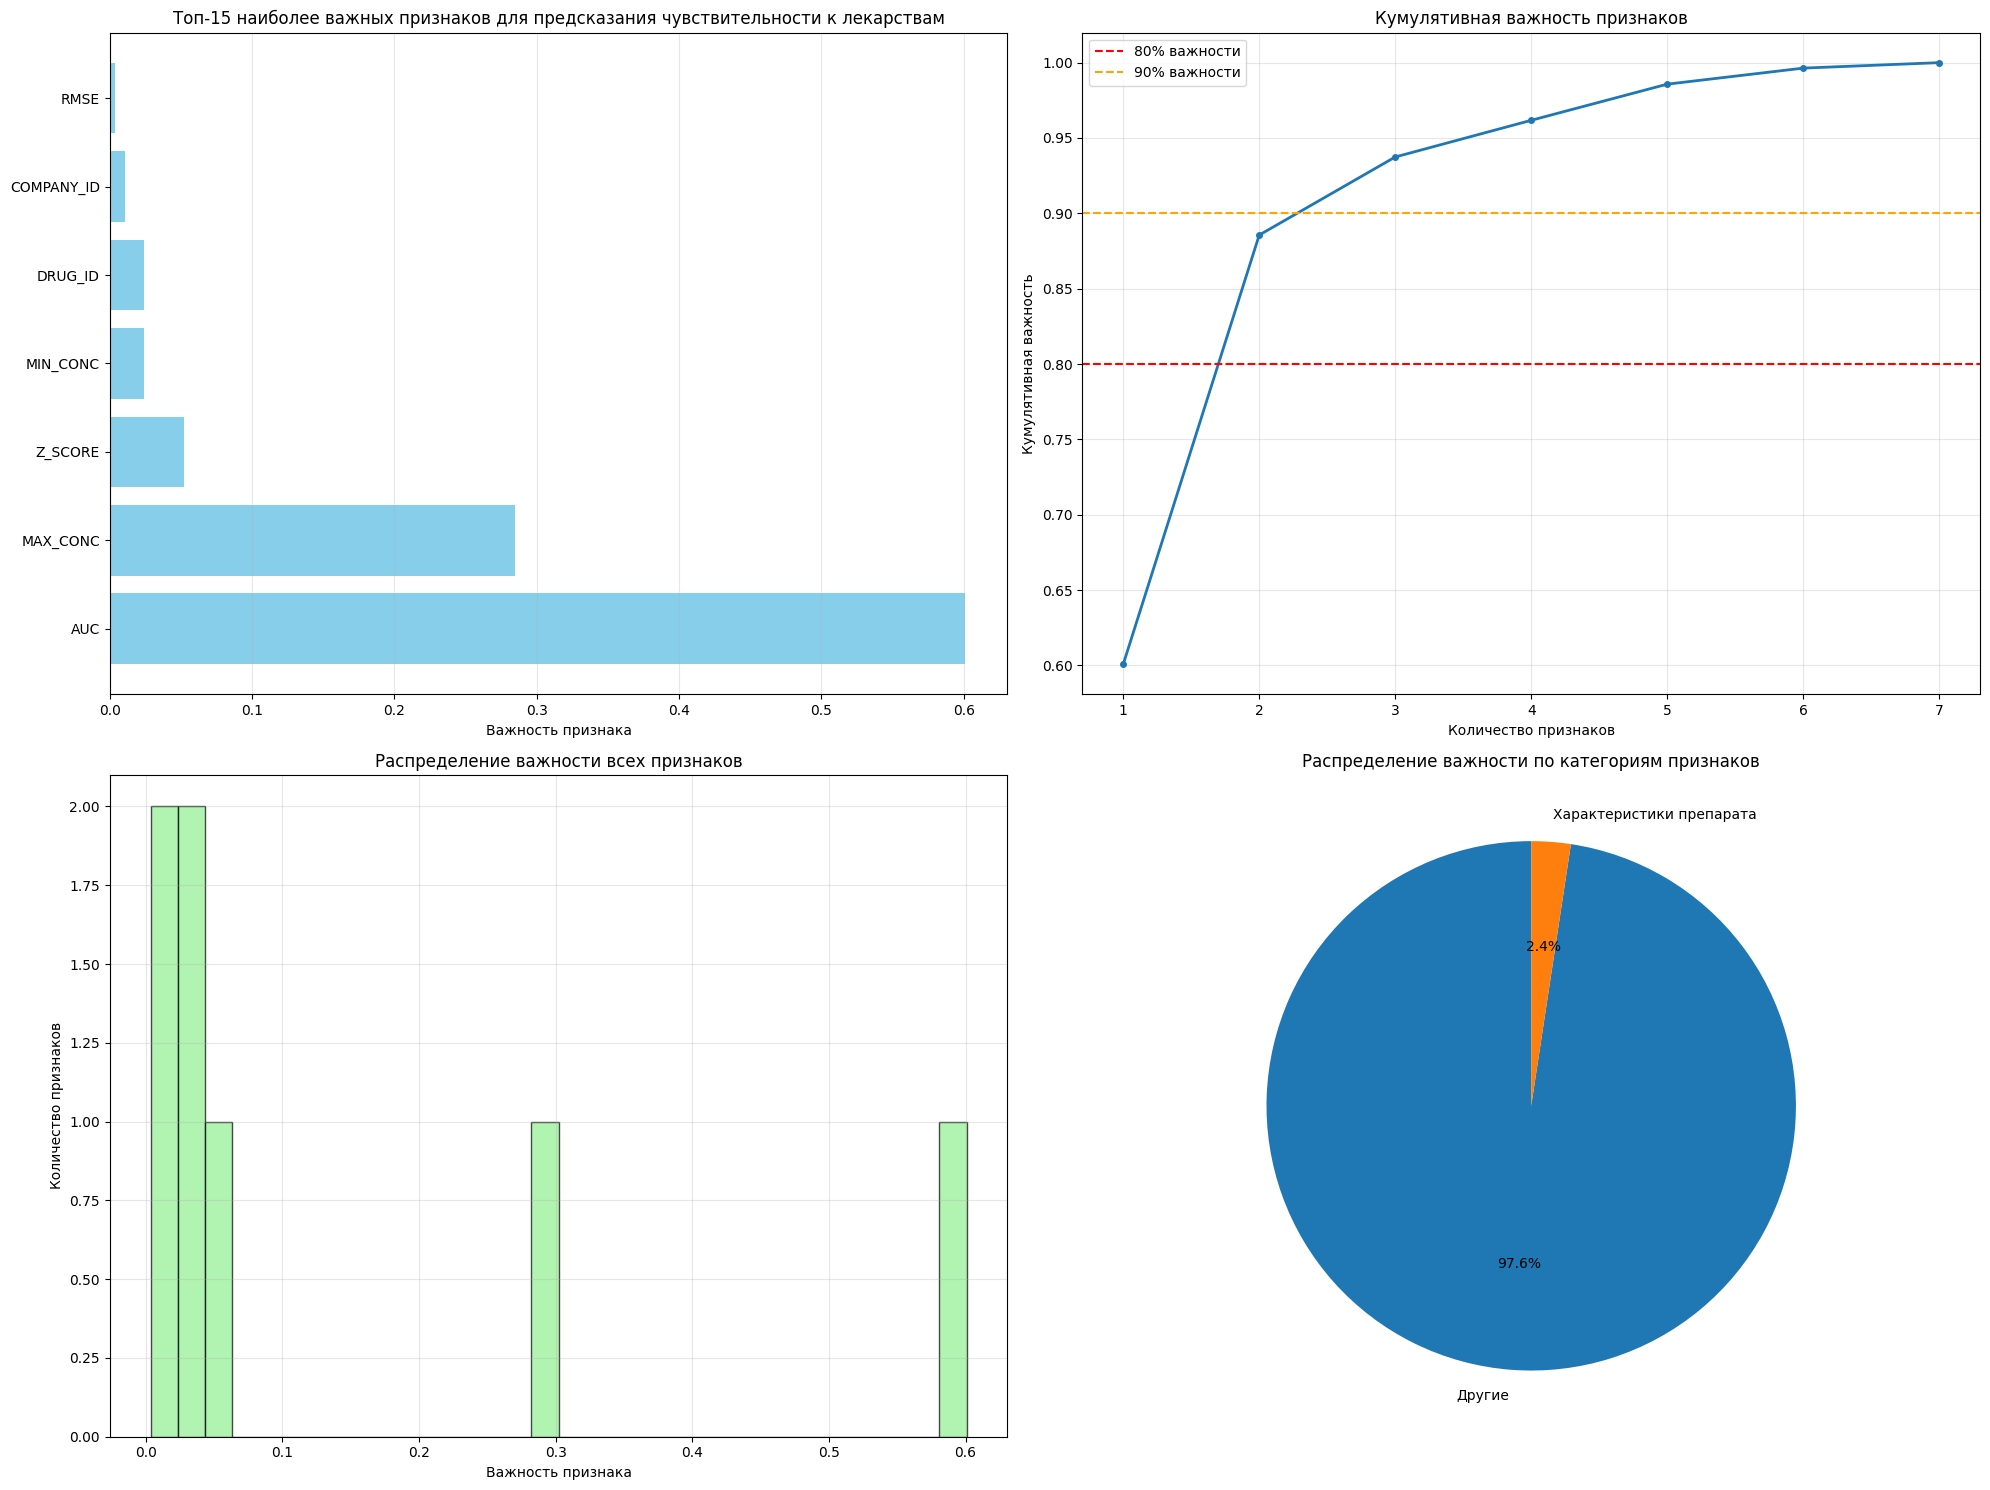

In [25]:
# 2. ВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# 2.1 Топ-15 важных признаков
top_features = feature_importance.head(15)
axes[0, 0].barh(top_features['feature'], top_features['importance'], color='skyblue')
axes[0, 0].set_xlabel('Важность признака')
axes[0, 0].set_title('Топ-15 наиболее важных признаков для предсказания чувствительности к лекарствам')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2.2 Кумулятивная важность признаков
cumulative_importance = np.cumsum(feature_importance['importance'])
axes[0, 1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 'o-', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.8, color='red', linestyle='--', label='80% важности')
axes[0, 1].axhline(y=0.9, color='orange', linestyle='--', label='90% важности')
axes[0, 1].set_xlabel('Количество признаков')
axes[0, 1].set_ylabel('Кумулятивная важность')
axes[0, 1].set_title('Кумулятивная важность признаков')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 2.3 Распределение важности всех признаков
axes[1, 0].hist(feature_importance['importance'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Важность признака')
axes[1, 0].set_ylabel('Количество признаков')
axes[1, 0].set_title('Распределение важности всех признаков')
axes[1, 0].grid(True, alpha=0.3)

# 2.4 Важность по категориям признаков (пример группировки)
# Группируем признаки по типам (замените на реальные категории ваших признаков)
def categorize_feature(feature_name):
    """Функция для категоризации признаков (адаптируйте под ваши данные)"""
    feature_lower = feature_name.lower()
    if 'gene' in feature_lower or 'expression' in feature_lower:
        return 'Экспрессия генов'
    elif 'mutation' in feature_lower or 'mut' in feature_lower:
        return 'Мутации'
    elif 'copy' in feature_lower or 'cna' in feature_lower:
        return 'Копии генов'
    elif 'pathway' in feature_lower:
        return 'Пути сигнализации'
    elif 'drug' in feature_lower:
        return 'Характеристики препарата'
    else:
        return 'Другие'

feature_importance['category'] = feature_importance['feature'].apply(categorize_feature)
category_importance = feature_importance.groupby('category')['importance'].sum().sort_values(ascending=False)

axes[1, 1].pie(category_importance.values, labels=category_importance.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Распределение важности по категориям признаков')

plt.tight_layout()
plt.show()

Модель демонстрирует исключительную производительность и представляет ценность как для исследовательских, так и для потенциальных клинических применений!